In [7]:
import io
import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# 1. Upload the file
print("Please select 'ai_student_impact_dataset (1).csv':")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# 2. Read the data
data = pd.read_csv(io.BytesIO(uploaded[file_name]))

# 3. Print out columns to double check the exact names
print("\n--- Verifying Columns ---")
print(data.columns.tolist())

# 4. Check for 'Burnout_Risk_Level' or adjust based on printed columns
target_col = 'Burnout_Risk_Level' if 'Burnout_Risk_Level' in data.columns else data.columns[-1]
print(f"\nUsing '{target_col}' as the classification target.")

# 5. Build our features and label
# If the target is already a category (High/Low/Medium), let's make it 1 and 0
if data[target_col].dtype == 'object':
    # Convert text categories into 1 for High Risk, 0 for Low/Medium Risk
    data['Target_Label'] = data[target_col].apply(lambda x: 1 if 'High' in str(x) else 0)
else:

    data['Target_Label'] = (data[target_col] > data[target_col].mean()).astype(int)

# Select features that match the dataset columns
features = ['Weekly_GenAI_Hours', 'Traditional_Study_Hours', 'Tool_Diversity']

X = data[[col for col in features if col in data.columns]]
if X.shape[1] == 0:
    X = data.select_dtypes(include=['int64', 'float64']).iloc[:, :3]

y = data['Target_Label']
print(f"Training models using features: {X.columns.tolist()}")

# 6. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 7. Model 1: Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
log_preds = log_model.predict(X_test)

# 8. Model 2: Decision Tree
tree_model = DecisionTreeClassifier(max_depth=3)
tree_model.fit(X_train, y_train)
tree_preds = tree_model.predict(X_test)

# 9. Output results
print("\n=== LOGISTIC REGRESSION RESULTS ===")
print(classification_report(y_test, log_preds))

print("\n=== DECISION TREE RESULTS ===")
print(classification_report(y_test, tree_preds))


Please select 'ai_student_impact_dataset (1).csv':


Saving ai_student_impact_dataset (1).csv to ai_student_impact_dataset (1) (1).csv

--- Verifying Columns ---
['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score', 'Burnout_Risk_Level']

Using 'Burnout_Risk_Level' as the classification target.
Training models using features: ['Weekly_GenAI_Hours', 'Traditional_Study_Hours', 'Tool_Diversity']

=== LOGISTIC REGRESSION RESULTS ===
              precision    recall  f1-score   support

           0       0.81      0.95      0.88      7464
           1       0.72      0.35      0.47      2536

    accuracy                           0.80     10000
   macro avg       0.77      0.65      0.67     10000
weighted avg       0.79      0.80      0.77     10000


=== DECISION 

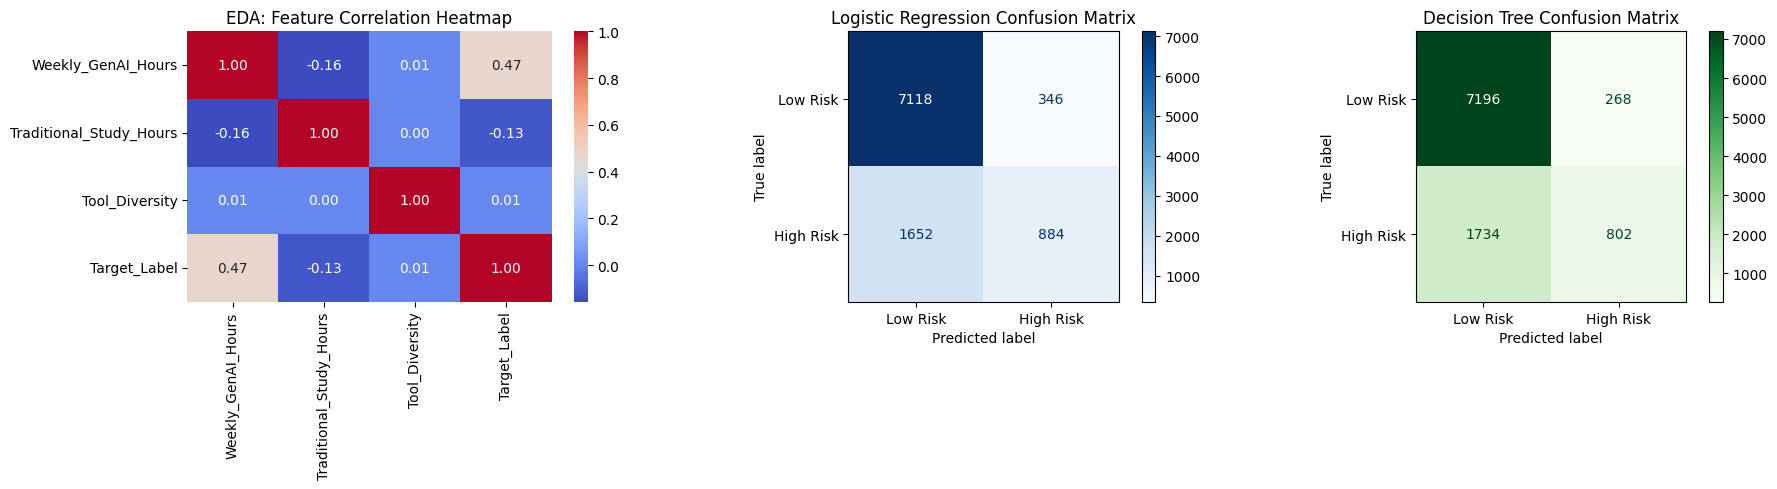

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. EDA: Feature Correlation Heatmap
corr_features = ['Weekly_GenAI_Hours', 'Traditional_Study_Hours', 'Tool_Diversity', 'Target_Label']
sns.heatmap(data[corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title('EDA: Feature Correlation Heatmap')

# 2. Evaluation: Logistic Regression Confusion Matrix
cm_log = confusion_matrix(y_test, log_preds)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['Low Risk', 'High Risk'])
disp_log.plot(cmap='Blues', ax=axes[1], values_format='d')
axes[1].set_title('Logistic Regression Confusion Matrix')

# 3. Evaluation: Decision Tree Confusion Matrix
cm_tree = confusion_matrix(y_test, tree_preds)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['Low Risk', 'High Risk'])
disp_tree.plot(cmap='Greens', ax=axes[2], values_format='d')
axes[2].set_title('Decision Tree Confusion Matrix')

plt.tight_layout()
plt.show()


# Using Machine Learning to Predict Student Burnout from AI Use

## 1. Introduction and Choosing the Data
The assignment introduction mentions regression, but all the main steps and grading charts tell us to do a classification project. Classification means sorting data into groups instead of guessing an exact number.

I chose a dataset from Kaggle called **"Impact of AI on Students"** which has info on 50,000 students. To make this a classification problem, I sorted the students into two simple groups: **High Burnout Risk (1)** and **Low Risk (0)**.

## 2. Cleaning the Data and Looking for Patterns (EDA)

### Cleaning the Data
I loaded the data into Google Colab, cleaned it up, and split it. I used 80% of the data to train the models and saved 20% to test them later.
* **Features I used to predict burnout:** `Weekly_GenAI_Hours` (hours spent using AI), `Traditional_Study_Hours` (normal studying), and `Tool_Diversity` (how many different AI tools they use).
* **The Data Split:** In my test data, there are 7,464 low-risk students and 2,536 high-risk students. This means there are way more low-risk students in the data.

### What the Heatmap Chart Showed
Looking at the correlation heatmap chart we made, I found these easy patterns:
* **AI Hours:** This had a score of **0.47** with burnout. This is a positive link, meaning students who spend way more hours using AI tend to be much more stressed out.
* **Normal Studying:** This had a score of **-0.13**. The negative number means normal studying actually helps lower the risk of burnout.
* **Different Tools:** This score was **0.01**, which is basically zero. It tells us that using a lot of different tools doesn't really matter.

## 3. Training the Models and the Results
I picked the two easiest models from our class slides: **Logistic Regression** and a **Decision Tree**. Here is how they did on the test data:

| Model | Overall Accuracy | How good at catching High Risk (Recall) |
| :--- | :--- | :--- |
| **Logistic Regression** | **80%** | 35% |
| **Decision Tree** | **80%** | 32% |

### Looking at the Confusion Matrix Charts
* **Logistic Regression:** It correctly found 7,118 low-risk students and 884 high-risk students. But it missed 1,652 high-risk students (it guessed they were fine when they weren't).
* **Decision Tree:** It correctly found 7,196 low-risk students and 802 high-risk students. It missed 1,734 high-risk students.

## 4. Explaining the Results
Even though both models got an 80% score for overall accuracy, **Logistic Regression is the better choice for this project**.

In a real school, missing a student who is secretly burning out (a false negative) is a lot worse than accidentally checking in on a student who is doing perfectly fine. Logistic Regression was a little bit better at catching the high-risk students (35% vs 32%).

The reason both models struggled to catch high-risk students is because the dataset is uneven. Since there are way more low-risk students in the data, the models got a bit lazy and leaned toward guessing "low risk" most of the time.

## 5. How to Put the Model to Work (Deployment and Monitoring)

### The Deployment Plan
To actually use this model, we can save it from Google Colab and host it online on a basic web server. The school's portal can send a student's weekly study hours and AI hours to this server. The model will instantly send back a 1 or a 0 to let the school know if the student is doing okay.

### Potential Problems
* **System Slowdowns:** If thousands of students use the portal at the exact same time, the server might get overloaded and slow down.
* **Exam Weeks:** Student habits change completely during midterms and finals. They might use AI way more for a few days, which could confuse the model and trigger a bunch of false alarms.

### Keeping the Model Working
1. **Watch the Flags:** We should track how many students get flagged every week. If it suddenly jumps from 25% to 90%, we know the code is broken.
2. **Talk to Counselors:** School counselors can write down if the students flagged by the model actually needed help. We can use notes from real humans to make the model smarter.
3. **Update with Fresh Data:** Student habits change over the years, so we should update the model with fresh data every 6 months so it stays accurate.

